# Report

Questo notebook verrà utilizzato per mostrare passo passo l'analisi fatta a partire dai dati grezzi fino alla creazione dei modelli di forecasting e la valutazione di essi.

## Approccio utilizzato

> 1. Descriptive analysis
> 2. Preprocessing
> 3. Modelli statistici baseline
> 4. Modelli ML non neurali
> 5. Modelli neurali
> 6. Confronto prestazionale
> 7. Inferential statistics sui confronti
> 8. Prescriptive analytics 

NB_Gli step 3-4-5 comprenderanno anche la parte di parameter fitting.


## 1. Analisi descrittiva (step by step)

In questa sezione riportiamo, nello stesso ordine del codice Python, metriche e grafici già generati in `Results/` per la serie **Produzione lorda totale**.

### 1.0 Caricamento dei risultati


In [56]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

# Risoluzione robusta della root progetto
project_root = Path.cwd()
if not (project_root / "Results").exists() and (project_root.parent / "Results").exists():
    project_root = project_root.parent

metrics_dir = project_root / "Results" / "metrics"
plots_dir = project_root / "Results" / "plots" / "descriptive"

# Caricamento metriche generate dallo script principale
series_df = pd.read_csv(metrics_dir / "tavola_1_14_series_clean_v1.csv")
freq_df = pd.read_csv(metrics_dir / "tavola_1_14_frequency_distribution_v1.csv")
central_df = pd.read_csv(metrics_dir / "tavola_1_14_central_tendency_v1.csv")
dispersion_df = pd.read_csv(metrics_dir / "tavola_1_14_dispersion_measures_v1.csv")
outliers_df = pd.read_csv(metrics_dir / "tavola_1_14_outliers_iqr_v1.csv")
outlier_summary_df = pd.read_csv(metrics_dir / "tavola_1_14_outliers_summary_v1.csv")

print(f"Project root: {project_root}")
print(f"Rows in cleaned series: {len(series_df)}")

Project root: c:\Users\giann\Documents\GitHub\FinalProject
Rows in cleaned series: 131


### 1.1 Serie base

Visualizzazione della serie annuale (1883 in avanti) per capirne l'andamento con un primo approccio visivo

,year,produzione_lorda_totale
0,1883,1.0
1,1884,2.0
2,1885,3.0
3,1886,3.0
4,1887,4.0
5,1888,5.0
6,1889,6.0
7,1890,8.0
8,1891,15.0
9,1892,22.0


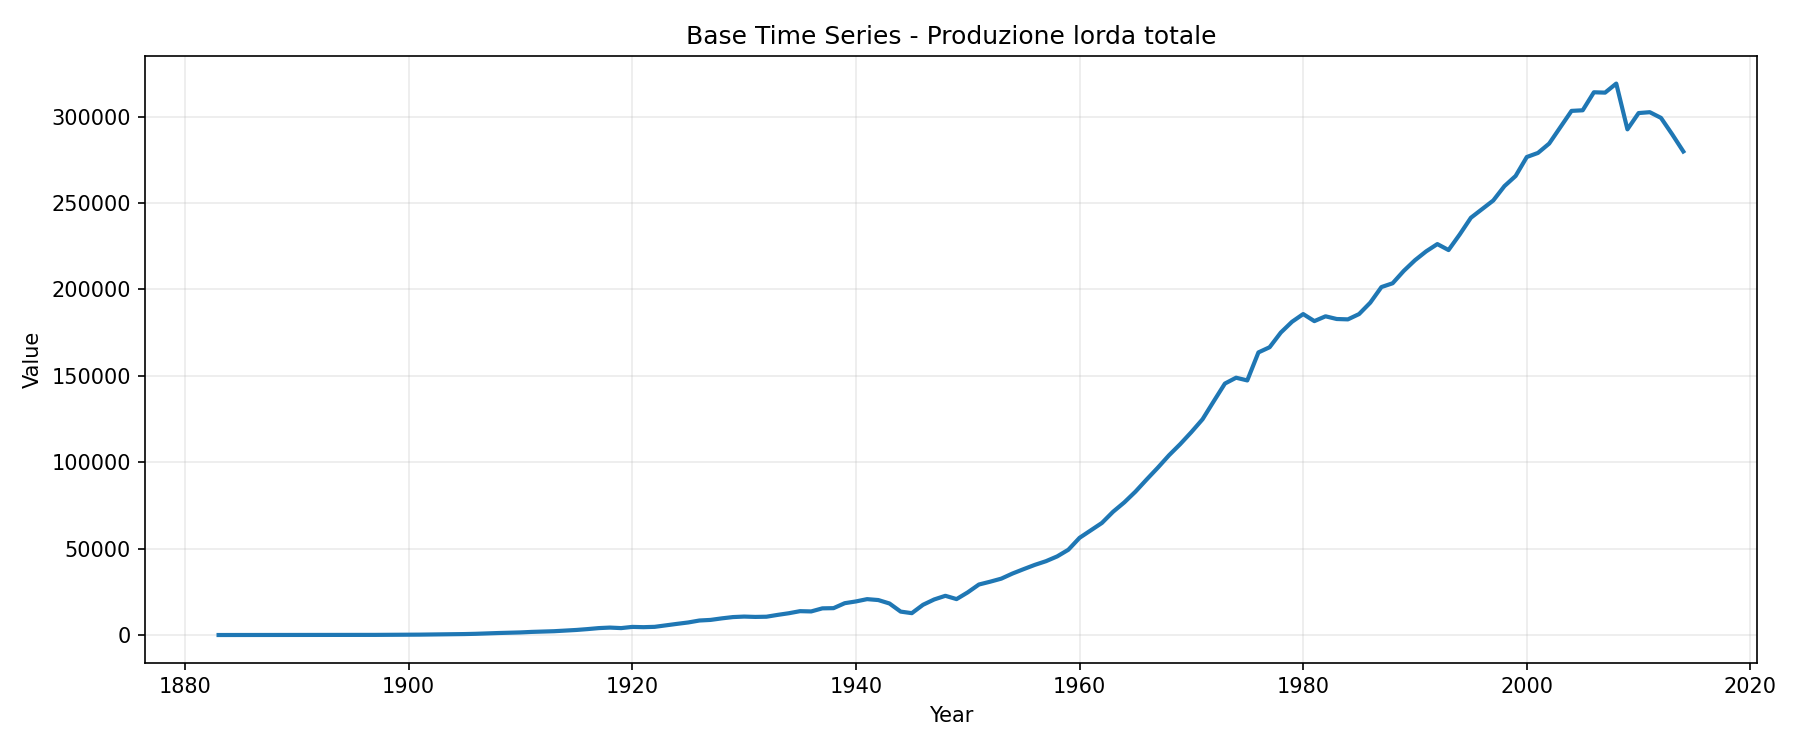

In [57]:
display(series_df.head(10))
display(Image(filename=str(plots_dir / "tavola_1_14_series_base_v1.png")))

### 1.2 Frequency distribution (empirica, relativa, bar chart)

La tabella seguente contiene le classi con frequenza assoluta e relativa.

,class_interval,absolute_frequency,relative_frequency
0,"(-318.13, 35459.778]",71,0.541985
1,"(35459.778, 70918.556]",9,0.068702
2,"(70918.556, 106377.333]",6,0.045802
3,"(106377.333, 141836.111]",4,0.030534
4,"(141836.111, 177294.889]",6,0.045802
5,"(177294.889, 212753.667]",11,0.083969
6,"(212753.667, 248212.444]",6,0.045802
7,"(248212.444, 283671.222]",6,0.045802
8,"(283671.222, 319130.0]",12,0.091603


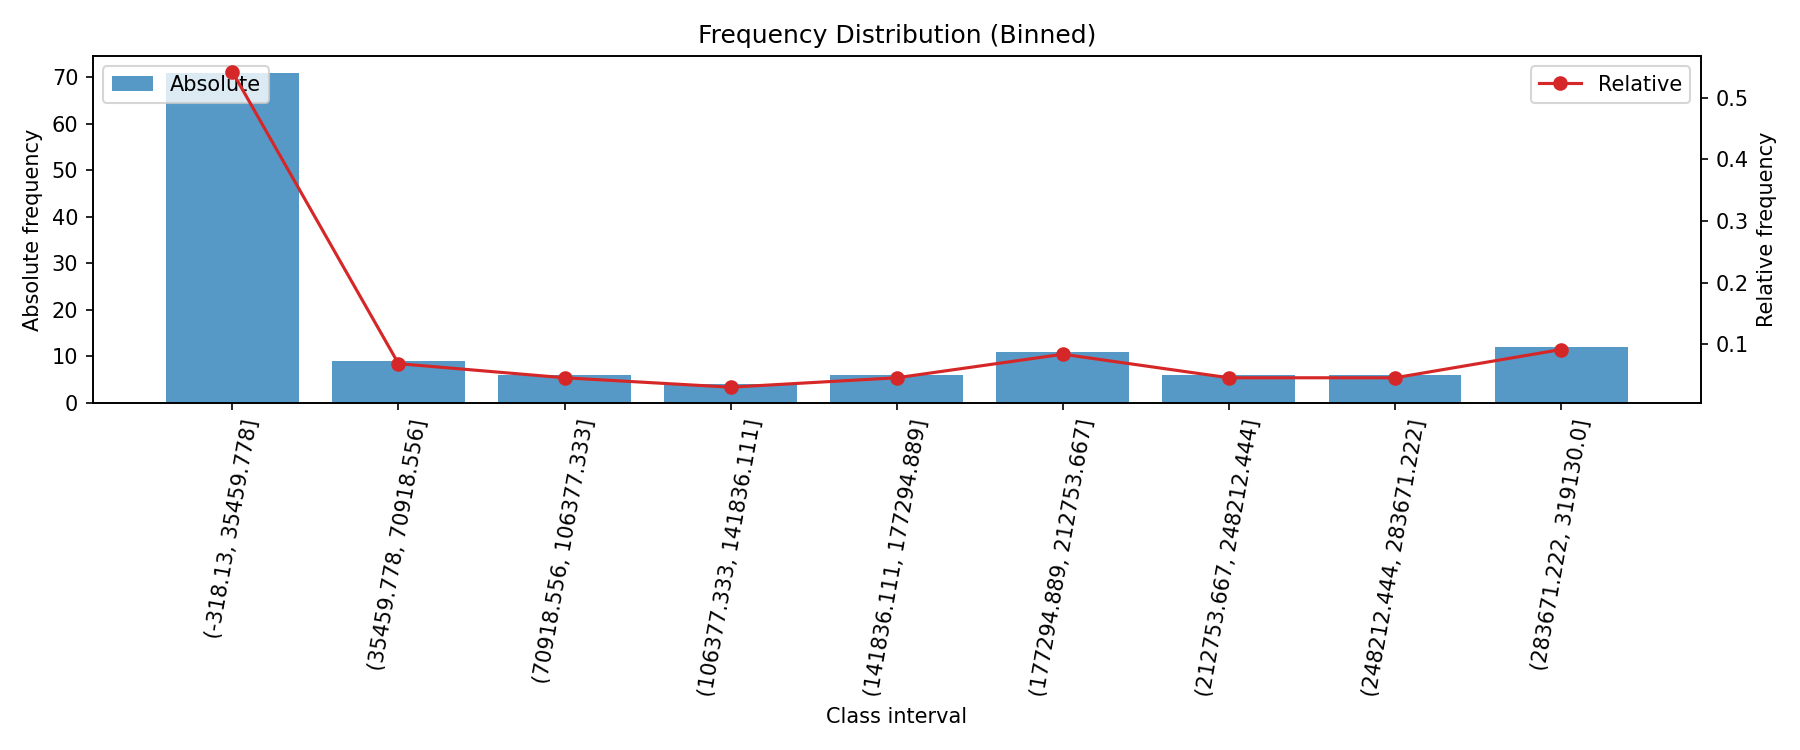

In [58]:
display(freq_df)
display(Image(filename=str(plots_dir / "tavola_1_14_frequency_distribution_v1.png")))

### 1.3 Central tendency e dispersion measures

Qui riportiamo media, mediana, moda, e poi range, varianza, deviazione standard, coefficiente di variazione e IQR.

In [59]:
display(central_df)
display(dispersion_df)

,mean,median,mode
0,88682.969466,20782.0,3.0


,range,variance,std_dev,coefficient_of_variation,iqr
0,319129.0,1.147613e+10,107126.719733,1.207974,178987.5


### 1.4 Outliers globali e studio della distribuzione

Outlier globali identificati con regola IQR sui livelli della serie. Per confronto coerente usiamo il boxplot sui livelli; in aggiunta mostriamo densita empirica vs fit normale/uniforme, distribuzione discreta e Q-Q plot.

,lower_fence,upper_fence,num_outliers,outlier_ratio
0,-265306.25,450643.75,0,0.0


,year,value


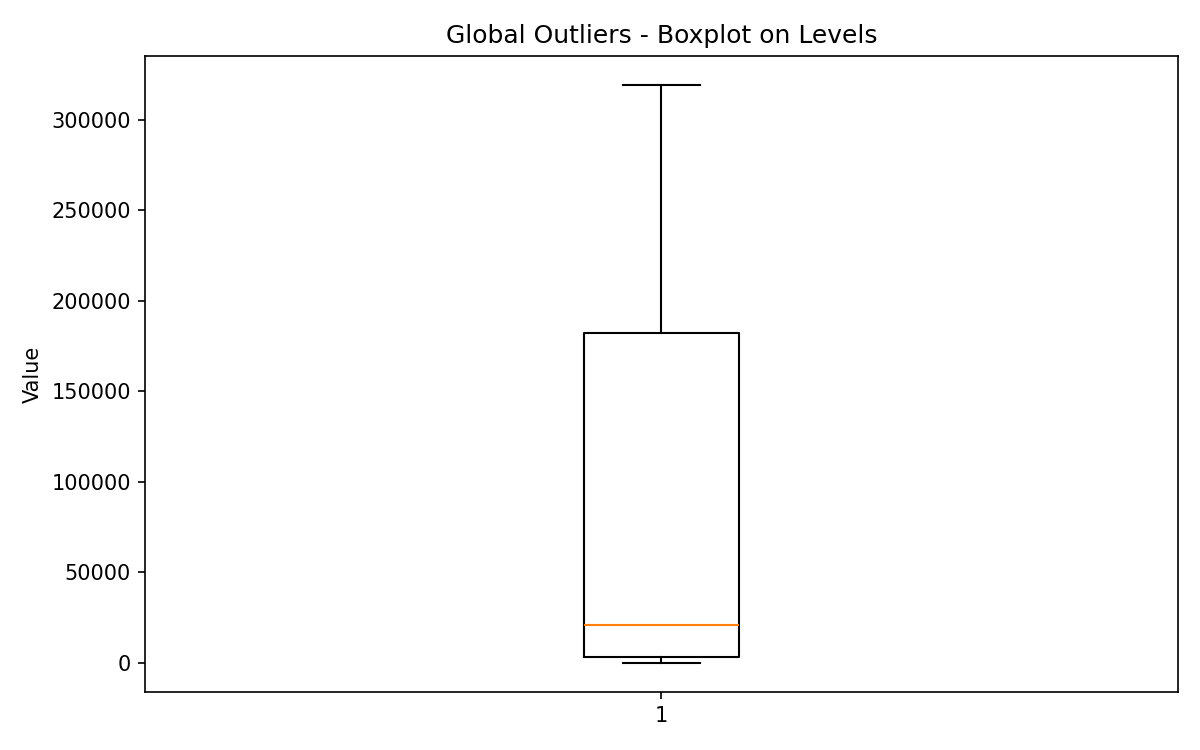

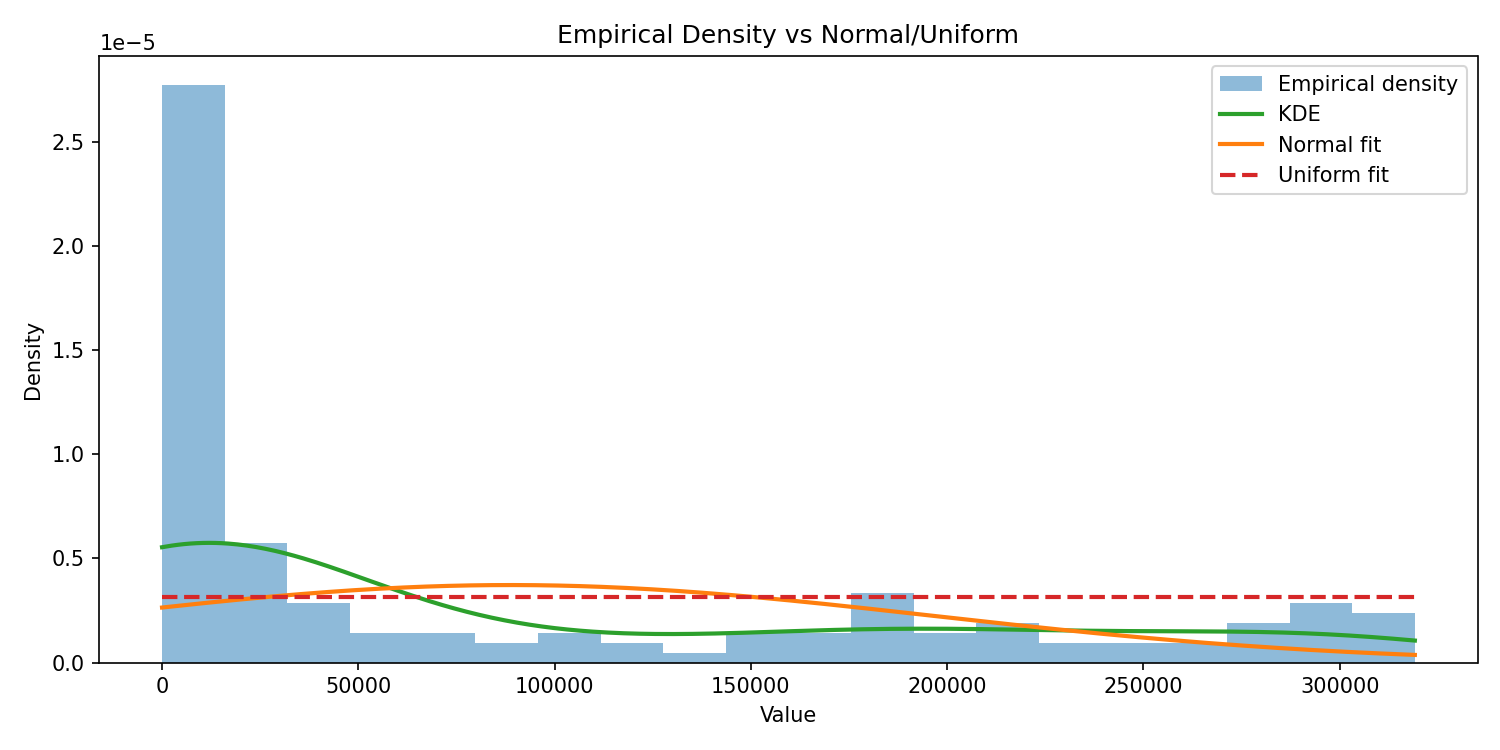

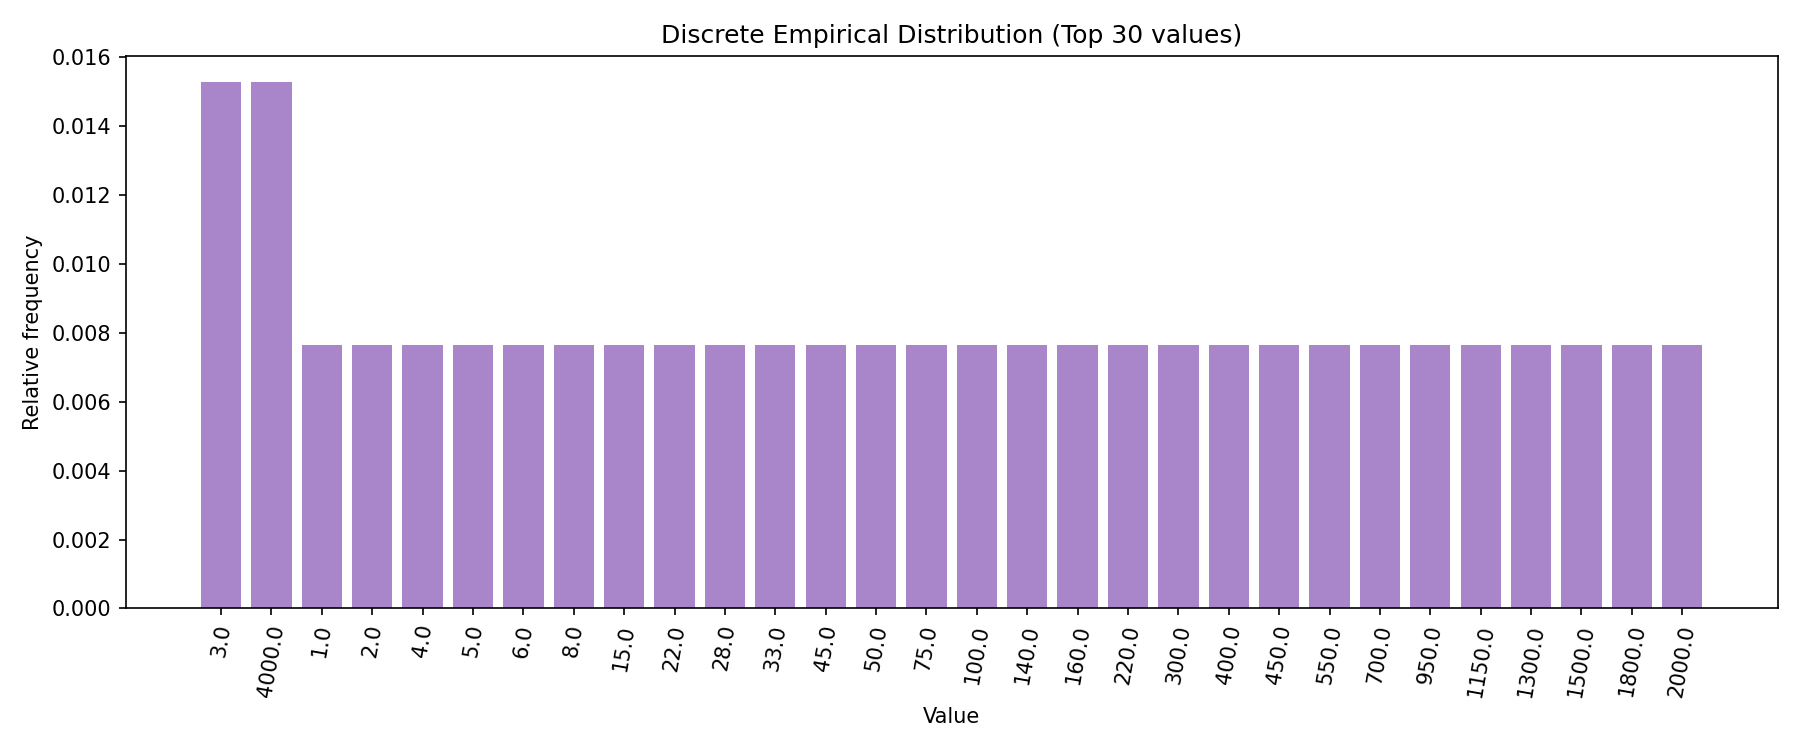

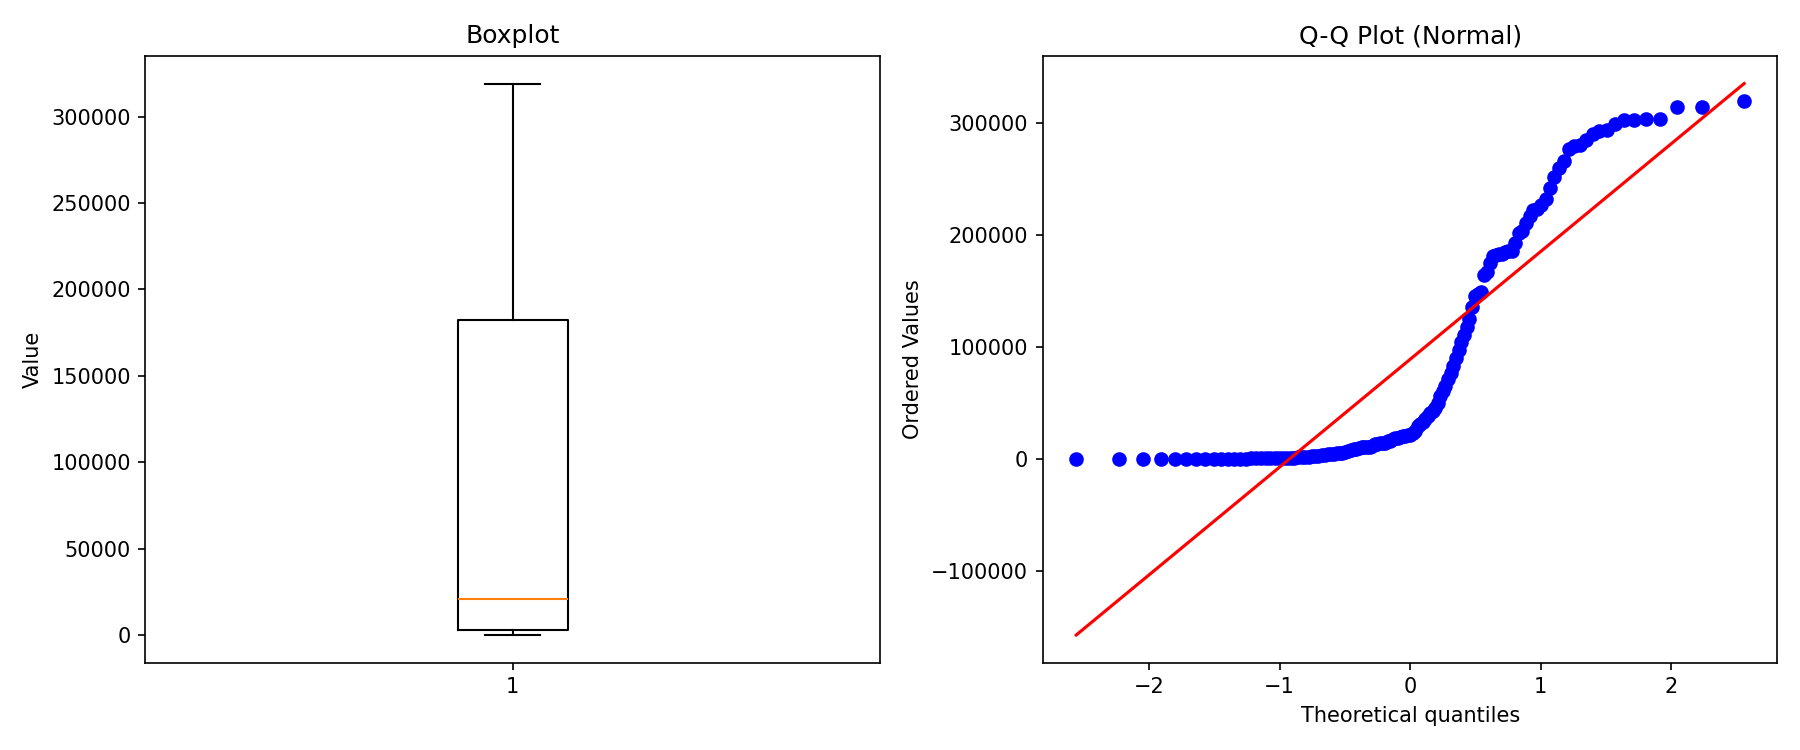

In [62]:
display(outlier_summary_df)
display(outliers_df.head(20))

# Stessa tipologia grafica usata anche per gli outlier locali (sezione 1.5)
display(Image(filename=str(plots_dir / "tavola_1_14_global_outliers_boxplot_v1.png")))

display(Image(filename=str(plots_dir / "tavola_1_14_density_comparison_v1.png")))
display(Image(filename=str(plots_dir / "tavola_1_14_discrete_distribution_v1.png")))
display(Image(filename=str(plots_dir / "tavola_1_14_outliers_qqplot_v1.png")))

### 1.5 Validazione numerica di trend crescente e anomalie locali

Per evitare che il trend globale nasconda variazioni anomale locali, analizziamo:

- trend lineare e correlazione con il tempo;
- variazioni anno su anno (YoY);
- outlier locali su YoY con baseline mobile (rolling median).

Per confronto omogeneo con la sezione 1.4, usiamo anche qui un boxplot (sulle variazioni YoY).

,n_observations,start_year,end_year,slope_per_year,slope_p_value,r_squared,spearman_rho,spearman_p_value,positive_yoy_share,negative_yoy_share,zero_yoy_share,intercept,slope_std_err
0,131,1883,2014,2548.968845,1.266610e-50,0.824752,0.997843,1.825742e-154,0.846154,0.146154,0.007692,-4.877059e+06,103.451136


,window,threshold,n_yoy_points,num_local_outliers,local_outlier_ratio,yoy_mean,yoy_std,yoy_q05,yoy_q95
0,11,3.5,130,2,0.015385,2152.523077,4700.087435,-2705.95,9580.6


,year,yoy_change,local_median_change,residual_vs_local,rolling_mad,local_score,is_local_outlier
0,1960,6890.0,4294.0,2596.0,256.0,6.839852,True
1,2009,-26488.0,351.0,-26839.0,5055.0,-3.581188,True


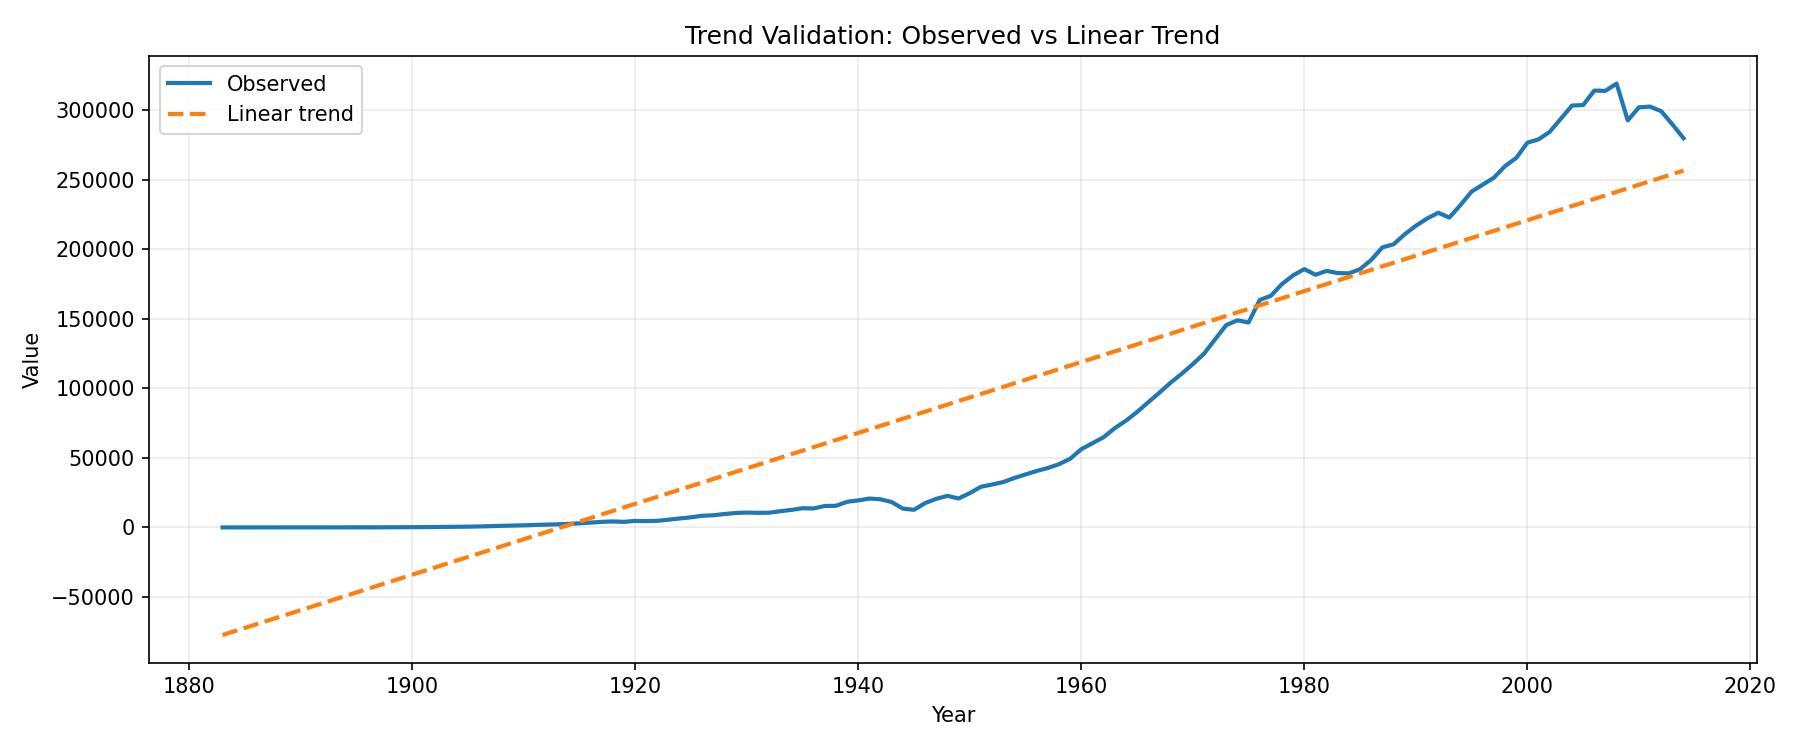

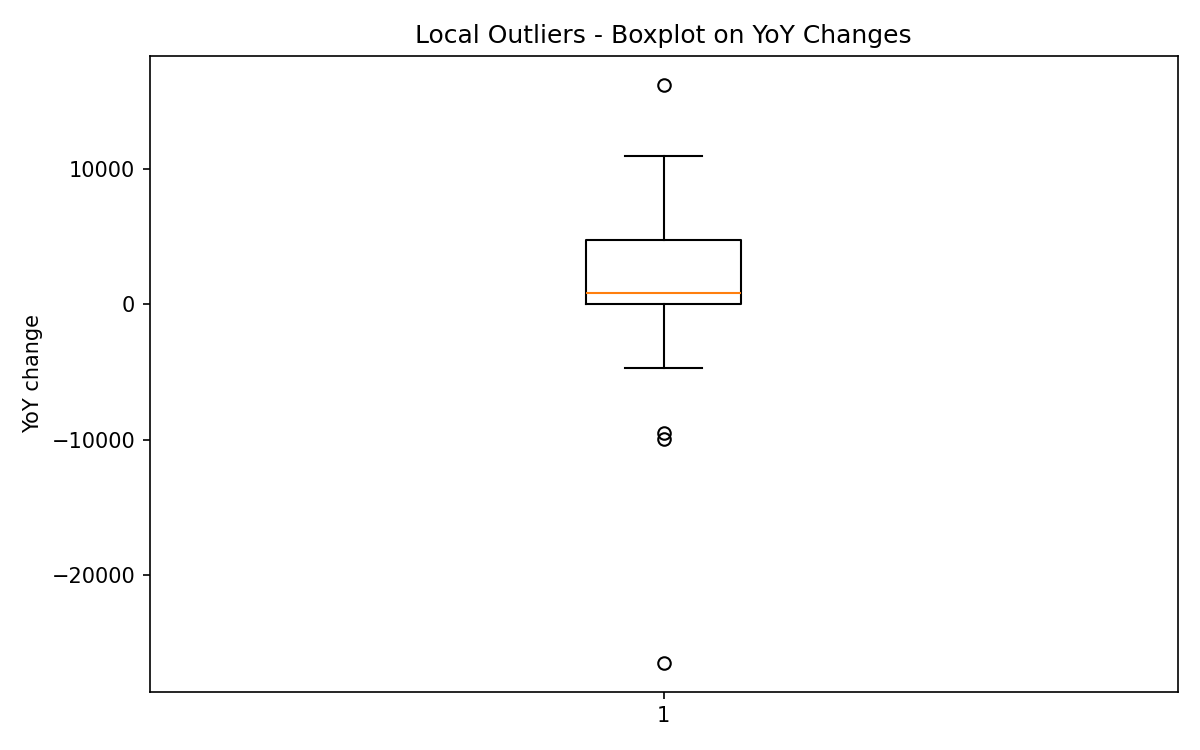

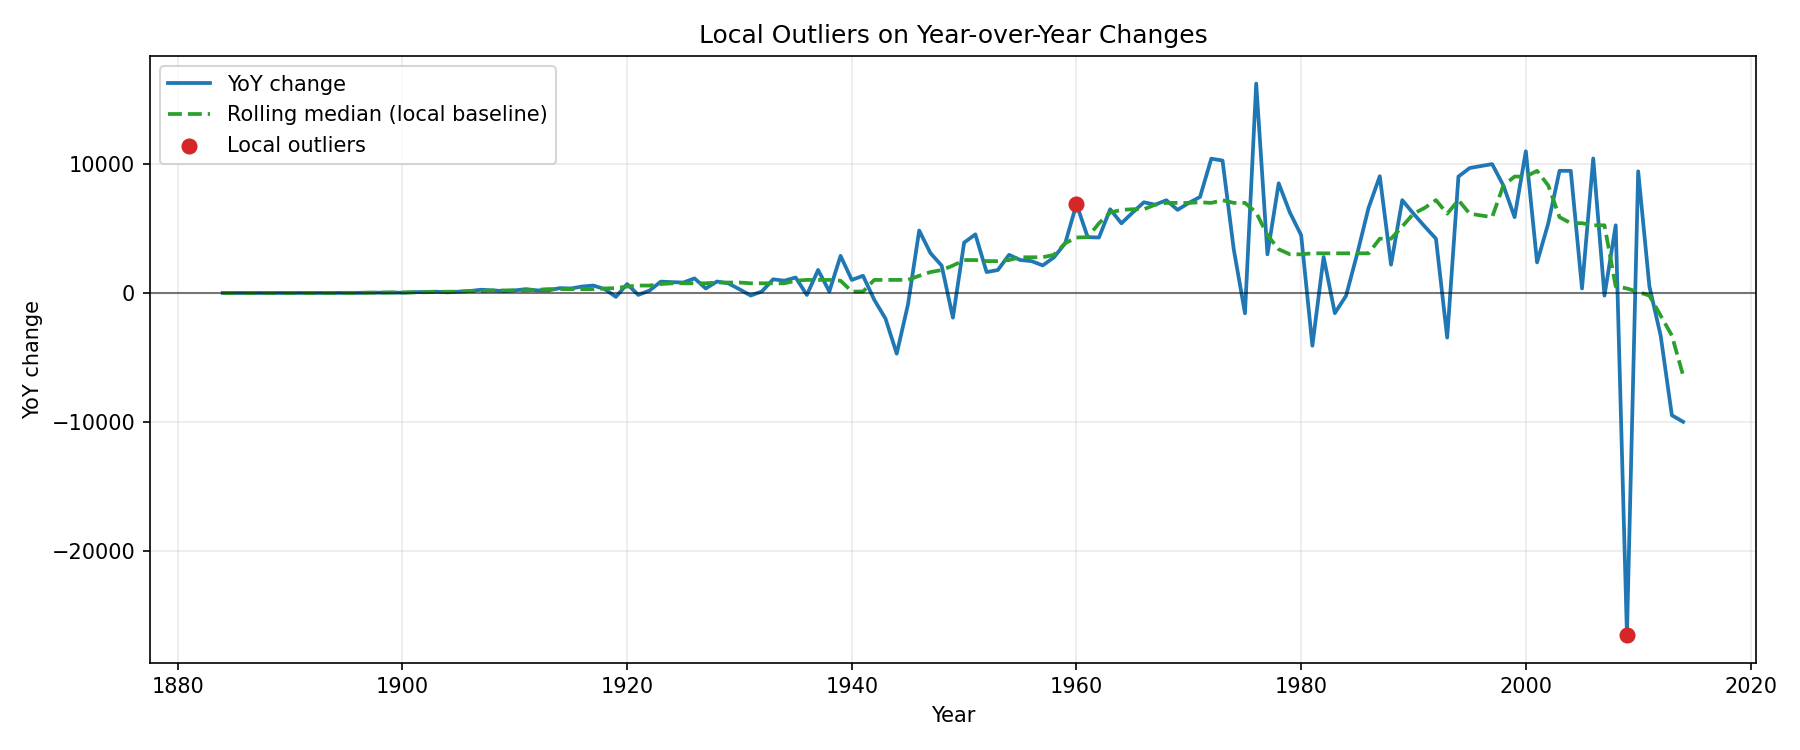

In [63]:
trend_summary_df = pd.read_csv(metrics_dir / "tavola_1_14_trend_summary_v1.csv")
local_outliers_summary_df = pd.read_csv(metrics_dir / "tavola_1_14_local_outliers_summary_v1.csv")
local_outliers_df = pd.read_csv(metrics_dir / "tavola_1_14_local_outliers_yoy_v1.csv")

display(trend_summary_df)
display(local_outliers_summary_df)
display(local_outliers_df)

display(Image(filename=str(plots_dir / "tavola_1_14_trend_validation_v1.png")))
display(Image(filename=str(plots_dir / "tavola_1_14_local_outliers_boxplot_v1.png")))
display(Image(filename=str(plots_dir / "tavola_1_14_local_outliers_yoy_v1.png")))

### 1.6 Confronto tra analisi globale e locale

Il confronto tra le due analisi mostra che non ci sono outlier globali sui livelli (IQR), ma emergono poche anomalie locali quando si osservano le variazioni anno-su-anno rispetto a una baseline mobile. Questo risultato e coerente con una serie a trend crescente: i valori elevati negli anni recenti non sono necessariamente anomali in senso assoluto, mentre alcuni salti o crolli puntuali rappresentano shock locali. Di conseguenza, nella fase di preprocessing e preferibile trattare queste osservazioni come eventi specifici della dinamica temporale, evitando rimozioni automatiche basate solo su soglie globali.

## 2. Preprocessing

In questa sezione applichiamo il preprocessing tenendo conto delle conclusioni della fase descrittiva: trend forte, assenza di outlier globali e presenza di pochi shock locali.

Checklist operativa adottata:

1. split temporale train/validation/test senza leakage;
2. trasformazioni candidate (nessuna, diff1, log1p+diff1, log1p+diff2);
3. test di stazionarieta su train (ADF + KPSS, Shapiro opzionale);
4. rilevazione outlier locali su variazioni YoY (rolling baseline);
5. scelta configurazione finale per lo Step 3.

Criterio decisionale per stazionarieta (train):
- ADF: p-value < 0.05
- KPSS: p-value >= 0.05

### 2.0 Setup e artefatti

Carichiamo una sola volta metriche e grafici generati dallo script, cosi le sottosezioni successive restano pulite e focalizzate.

In [68]:
preproc_metrics_dir = project_root / "Results" / "metrics"
preproc_plots_dir = project_root / "Results" / "plots" / "preprocessing"

preproc_split_df = pd.read_csv(preproc_metrics_dir / "tavola_1_14_preproc_split_summary_v1.csv")
preproc_tests_df = pd.read_csv(preproc_metrics_dir / "tavola_1_14_preproc_tests_v1.csv")
preproc_candidates_df = pd.read_csv(preproc_metrics_dir / "tavola_1_14_preproc_candidate_tests_v1.csv")
preproc_local_outliers_df = pd.read_csv(preproc_metrics_dir / "tavola_1_14_preproc_local_outliers_v1.csv")

preproc_candidates_ranked = preproc_candidates_df.sort_values("adf_pvalue_train")
best_stationary = preproc_candidates_ranked[
    (preproc_candidates_ranked["adf_stationary_train"] == True)
    & (preproc_candidates_ranked["kpss_stationary_train"] == True)
]

best_cfg_row = (best_stationary.head(1) if len(best_stationary) > 0 else preproc_candidates_ranked.head(1)).iloc[0]

### 2.1 Split temporale

Lo split viene fatto in ordine cronologico, senza shuffle, per evitare leakage tra passato e futuro.

,split,start,end,n
0,train,1885,1974,90
1,val,1975,1993,19
2,test,1994,2014,20


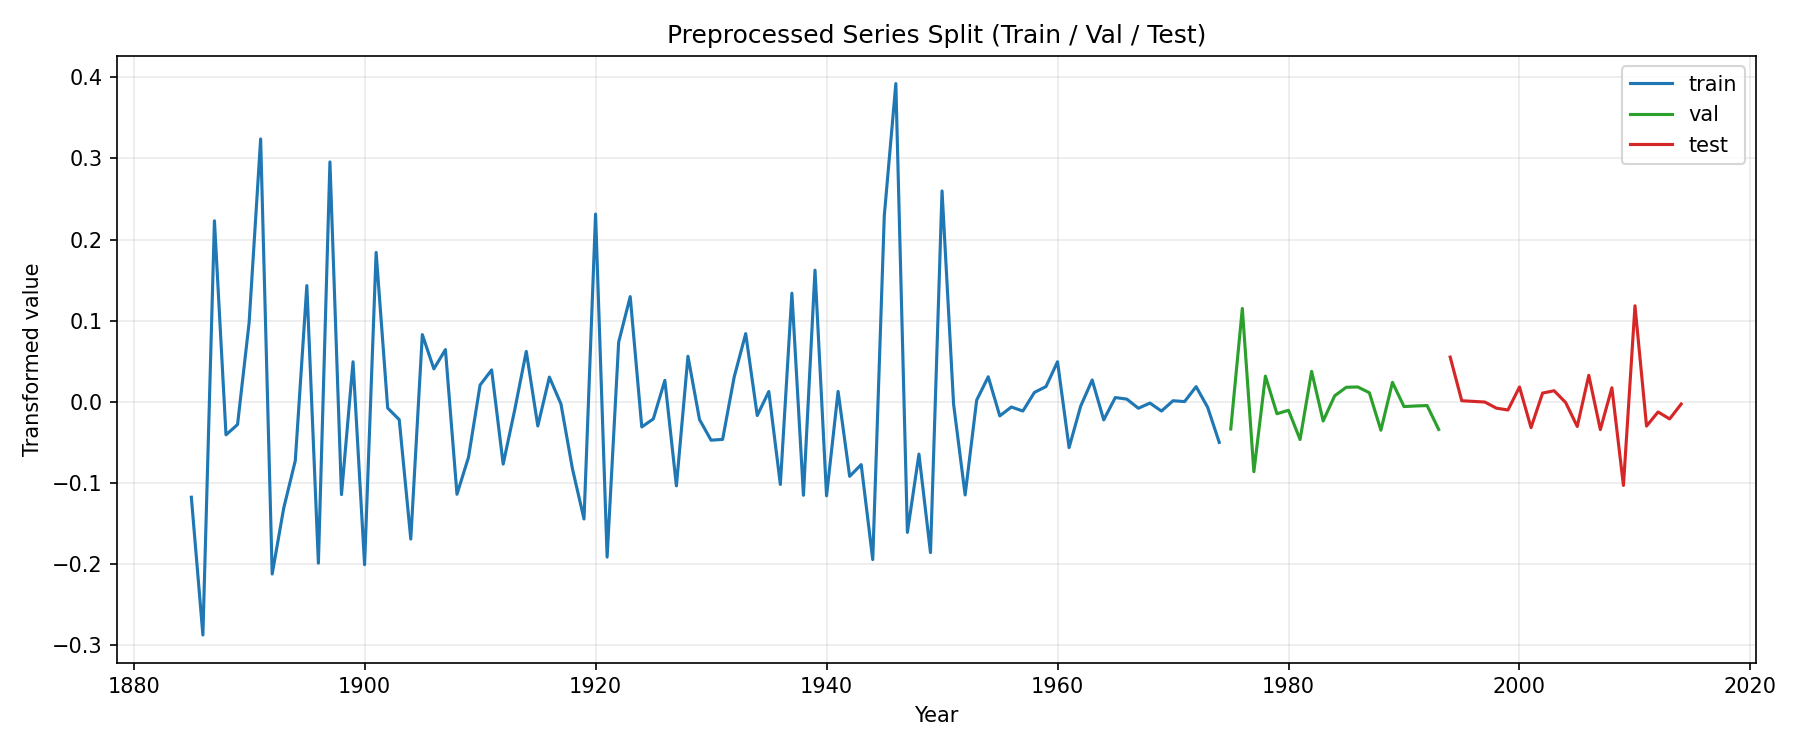

In [69]:
display(preproc_split_df)
display(Image(filename=str(preproc_plots_dir / "tavola_1_14_preproc_split_view_v1.png")))

### 2.2 Trasformazioni candidate

Confrontiamo le configurazioni candidate usando i test sul train, poi selezioniamo quella che soddisfa meglio il criterio ADF+KPSS.

,use_log1p,power_exponent,diff_order,scale_method,adf_pvalue_train,kpss_pvalue_train,adf_stationary_train,kpss_stationary_train
3,True,NaN,2,none,6.055981e-18,0.10,True,True
2,True,NaN,1,none,5.285964e-01,0.01,False,False
1,False,NaN,1,none,9.692541e-01,0.01,False,False
0,False,NaN,0,none,1.000000e+00,0.01,False,False


,use_log1p,power_exponent,diff_order,scale_method,adf_pvalue_train,kpss_pvalue_train,adf_stationary_train,kpss_stationary_train
3,True,NaN,2,none,6.055981e-18,0.1,True,True


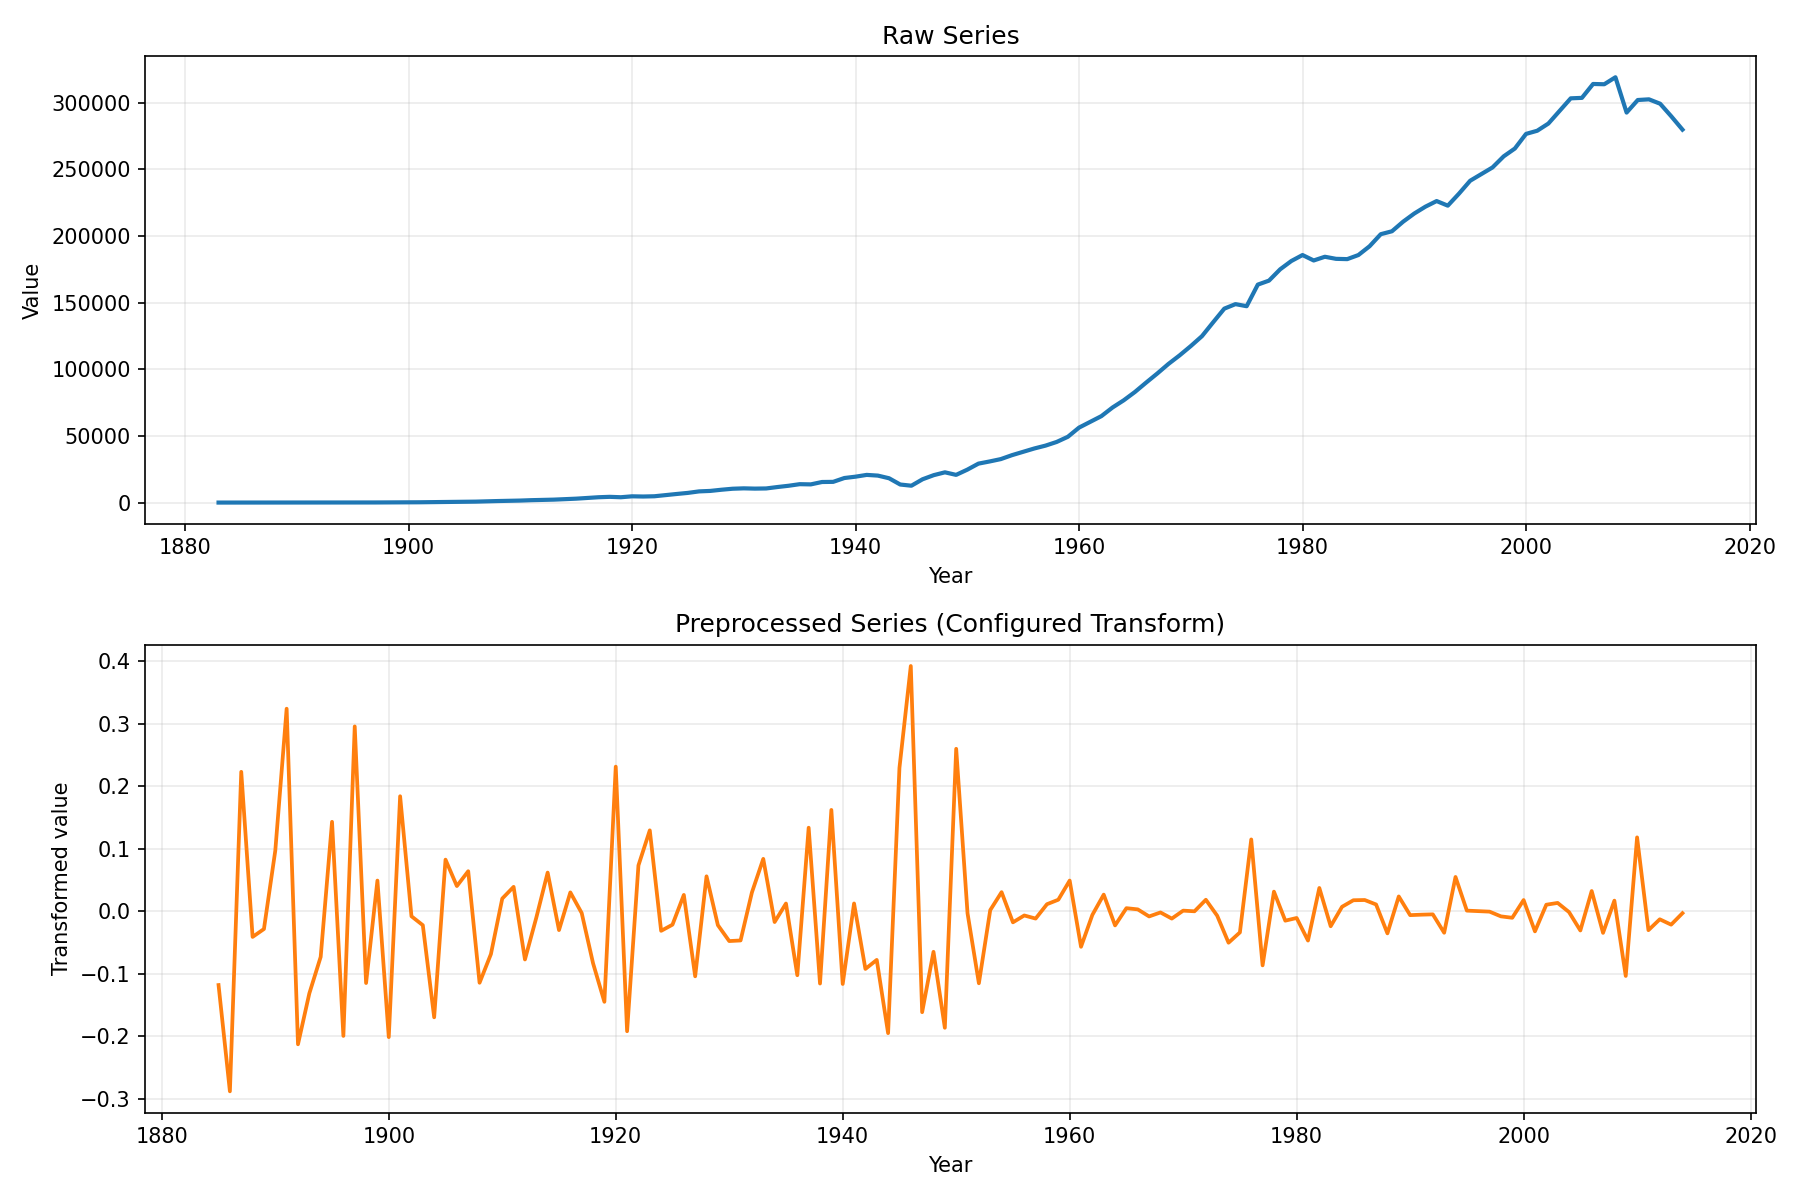

In [70]:
display(preproc_candidates_ranked)
display(best_stationary.head(1) if len(best_stationary) > 0 else preproc_candidates_ranked.head(1))
display(Image(filename=str(preproc_plots_dir / "tavola_1_14_preproc_raw_vs_transformed_v1.png")))

### 2.3 Test di stazionarieta

Valutiamo ADF e KPSS su train/validation/test e annotiamo la decisione principale sul train set.

,split,n,adf_stat,adf_pvalue,adf_stationary_at_05,kpss_stat,kpss_pvalue,kpss_stationary_at_05,shapiro_stat,shapiro_pvalue,shapiro_normal_at_05,kpss_note
0,train,90,-10.198528,6.055981e-18,True,0.150338,0.100000,True,0.950601,0.001823,False,The test statistic is outside of the range of ...
1,val,19,-8.754091,2.785604e-14,True,0.273710,0.100000,True,0.933447,0.200395,True,The test statistic is outside of the range of ...
2,test,20,-1.107350,7.121318e-01,False,0.359939,0.094423,True,0.902722,0.046394,False,NaN


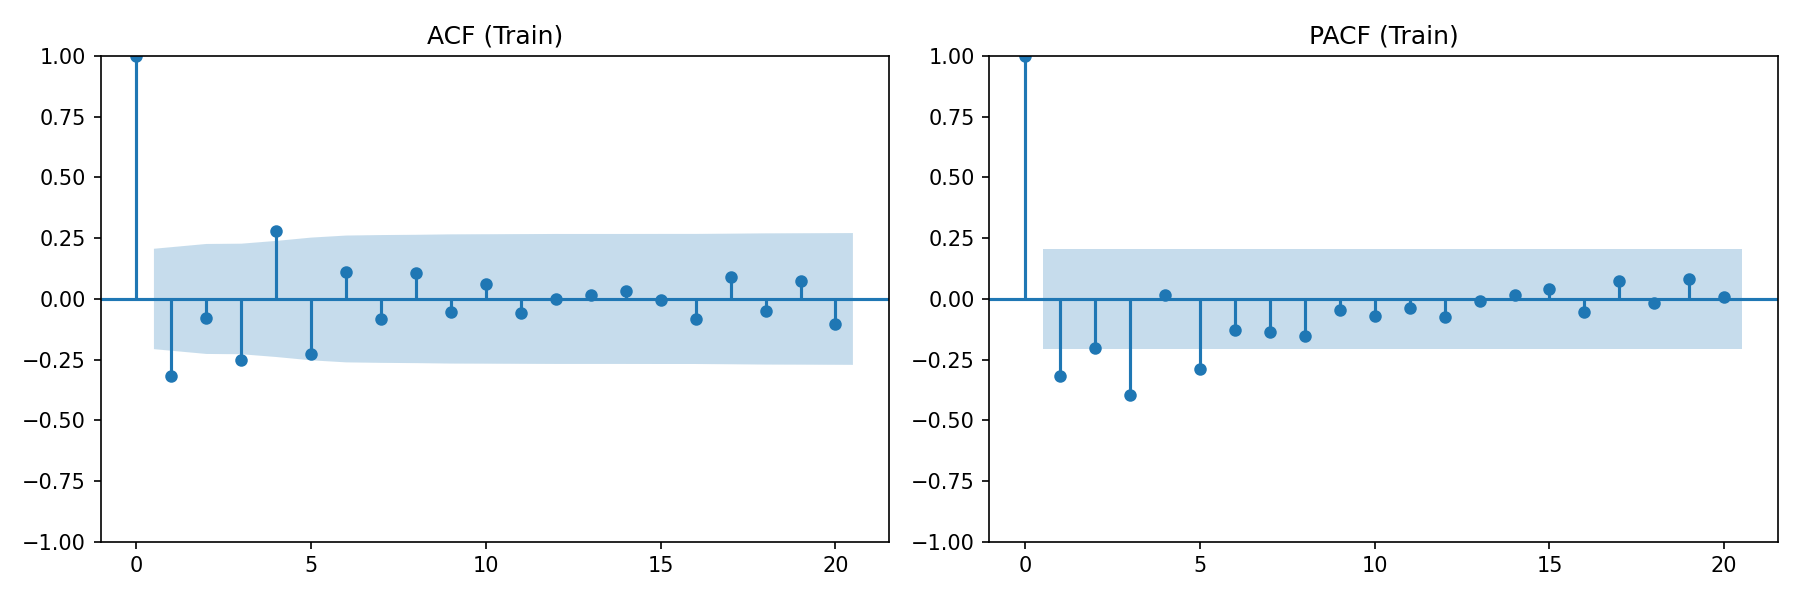

Train - criterio stazionarieta:
ADF p-value = 6.05598e-18 -> OK
KPSS p-value = 0.1 -> OK


In [71]:
display(preproc_tests_df)
display(Image(filename=str(preproc_plots_dir / "tavola_1_14_preproc_acf_pacf_v1.png")))

train_tests = preproc_tests_df.loc[preproc_tests_df["split"] == "train"].iloc[0]
print("Train - criterio stazionarieta:")
print(f"ADF p-value = {train_tests['adf_pvalue']:.6g} -> {'OK' if bool(train_tests['adf_stationary_at_05']) else 'NO'}")
print(f"KPSS p-value = {train_tests['kpss_pvalue']:.6g} -> {'OK' if bool(train_tests['kpss_stationary_at_05']) else 'NO'}")

### 2.4 Rilevazione outlier locali su variazioni YoY

Gli outlier locali vengono stimati sulle variazioni anno-su-anno rispetto a una baseline mobile, in coerenza con quanto visto nello Step 1.

,year,yoy_change,rolling_median,rolling_mad,local_score,is_local_outlier
76,1960,6890.0,4294.0,256.0,6.839852,True
124,2009,-26488.0,351.0,5055.0,-3.581188,True


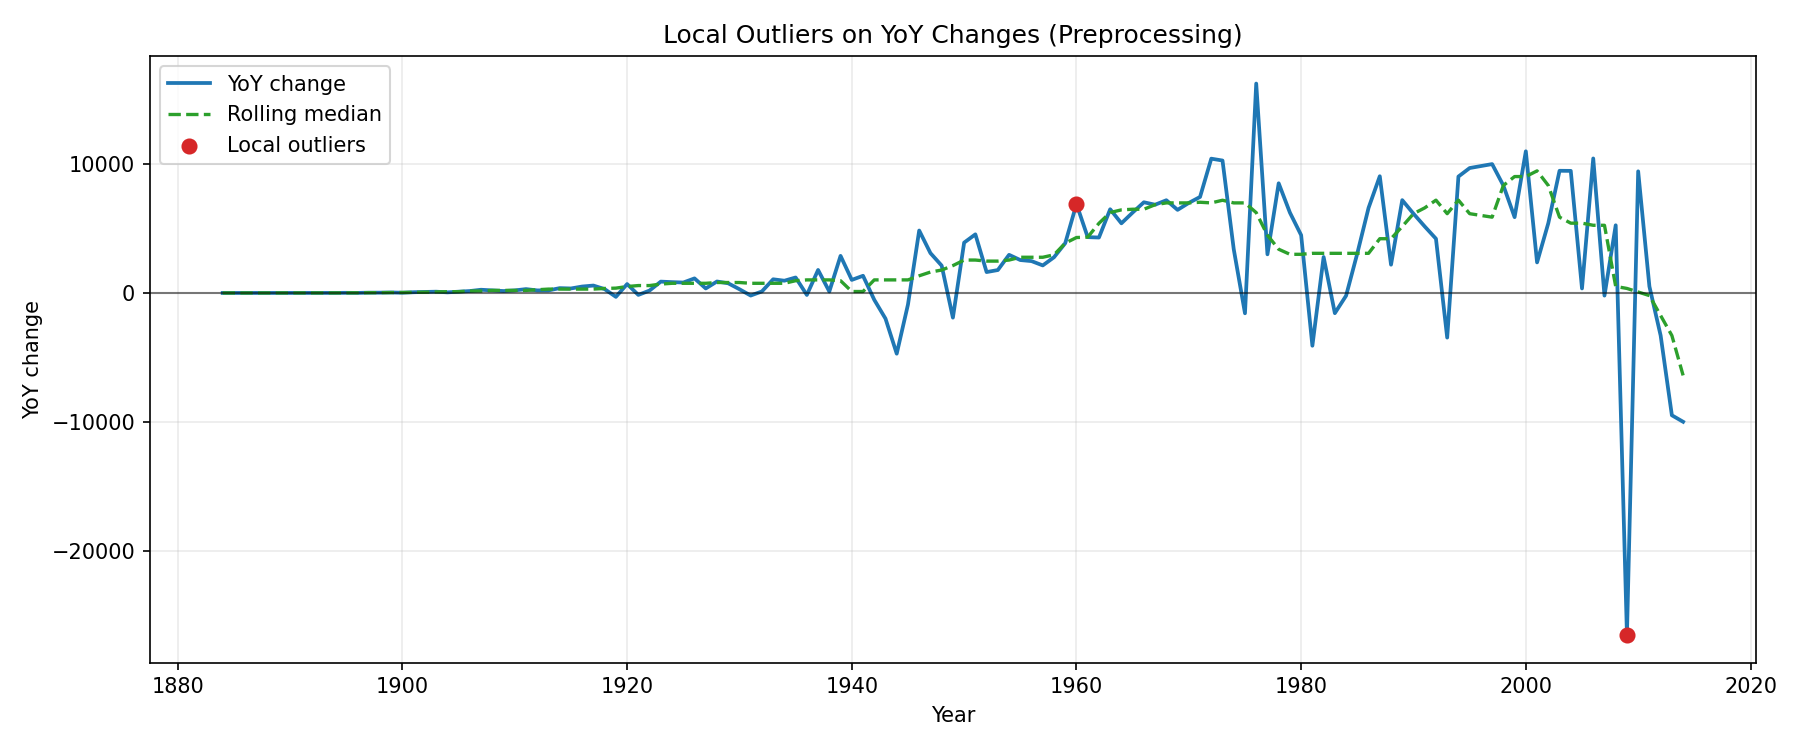

In [72]:
display(preproc_local_outliers_df[preproc_local_outliers_df["is_local_outlier"] == True].head(20))
display(Image(filename=str(preproc_plots_dir / "tavola_1_14_preproc_local_outliers_v1.png")))

### 2.5 Preprocessing Conclusion: Statistical

Configurazione consigliata per il modello statistico: **log1p + differencing di ordine 2** (senza scaling).
Motivazione: nella selezione delle candidate, questa e la configurazione che soddisfa il criterio di stazionarieta sul train (ADF significativo e KPSS non significativo).

### 2.6 Preprocessing Conclusion: Non-Neural ML

Per i modelli ML non neurali manteniamo la stessa pipeline base (coerenza sperimentale), ma consideriamo come adattamento a valle il feature engineering su lag e, se necessario, scaling.
Configurazione iniziale: **log1p + diff2** come baseline condivisa; eventuale confronto secondario con livelli scalati nel solo ramo ML.

### 2.7 Preprocessing Conclusion: Neural Network

Per i modelli neurali usiamo la stessa base di preprocessing per mantenere comparabilita con gli altri modelli, applicando poi nel blocco Neural il windowing e l'eventuale scaling specifico (fit solo su train).
Configurazione baseline di input: **log1p + diff2**, con possibilita di esperimento aggiuntivo su livelli scalati come analisi di sensibilita.

### 2.8 Final Decision Table

Tabella sintetica delle decisioni di preprocessing per famiglia modello.

In [73]:
final_preproc_decisions = pd.DataFrame(
    [
        {
            "model_family": "Statistical",
            "base_transform": "log1p + diff2",
            "input_scale": "no scaling",
            "notes": "Target stazionario su train secondo ADF+KPSS.",
        },
        {
            "model_family": "Non-Neural ML",
            "base_transform": "log1p + diff2",
            "input_scale": "optional (fit on train only)",
            "notes": "Stessa baseline per comparabilita; feature lag nel ramo ML.",
        },
        {
            "model_family": "Neural Network",
            "base_transform": "log1p + diff2",
            "input_scale": "optional (fit on train only)",
            "notes": "Windowing sequenziale e tuning specifico nel ramo neural.",
        },
    ]
)

final_preproc_decisions

,model_family,base_transform,input_scale,notes
0,Statistical,log1p + diff2,no scaling,Target stazionario su train secondo ADF+KPSS.
1,Non-Neural ML,log1p + diff2,optional (fit on train only),Stessa baseline per comparabilita; feature lag...
2,Neural Network,log1p + diff2,optional (fit on train only),Windowing sequenziale e tuning specifico nel r...
